# Import e set-up iniziale

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from pyvis.network import Network
import warnings

# Ignoriamo i warning sui dtypes misti per letture veloci
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Setup grafica
sns.set_theme(style="whitegrid")
print("✅ Librerie caricate con successo. Ambiente pronto.")

✅ Librerie caricate con successo. Ambiente pronto.


In [2]:
# ==========================================
# SELEZIONE MODALITÀ DI ANALISI
# ==========================================
# 1 = Solo Mutazioni (SNV)
# 2 = Solo CNA (Amplificazioni/Delezioni)
# 3 = Solo SV (Varianti Strutturali)
# 4 = Integrata (Mut + CNA + SV) 

ANALYSIS_MODE = 1

## Filtri

In [3]:
# ==========================================
# CELLA 2: FILTRO PAZIENTI SULLE MUTAZIONI
# ==========================================
def filter_samples_by_id(reference_filename, target_files_list, folder_path, output_prefix="F_"):
    reference_csv_path = os.path.join(folder_path, reference_filename)
    
    try:
        ref_df = pd.read_csv(reference_csv_path, sep='\t')
        valid_ids = set(ref_df['Sample_Id'].astype(str).unique())
        print(f"\n--- {folder_path.upper()} ---")
        print(f"[*] ID validi nel master: {len(valid_ids)}")
    except Exception as e:
        print(f"[!] Errore master {reference_csv_path}: {e}")
        return

    for filename in target_files_list:
        file_input_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_input_path): continue
            
        target_df = pd.read_csv(file_input_path, sep='\t')
        
        if 'Sample_Id' in target_df.columns:
            filtered_df = target_df[target_df['Sample_Id'].astype(str).isin(valid_ids)]
            output_full_path = os.path.join(folder_path, f"{output_prefix}{filename}")
            filtered_df.to_csv(output_full_path, index=False, sep='\t')
            print(f"[*] Mutazioni filtrate salvate: {output_full_path} ({len(filtered_df)} righe)")

file_da_filtrare = ["data_mutations.txt"] 
filter_samples_by_id('F_nokras_pancreas.csv', file_da_filtrare, "./kras_pancreas/")
filter_samples_by_id('F_nokras_lung.csv', file_da_filtrare, "./kras_lung/")
filter_samples_by_id('F_nokras_colon.csv', file_da_filtrare, "./kras_colon/")


--- ./KRAS_PANCREAS/ ---
[*] ID validi nel master: 1672
[*] Mutazioni filtrate salvate: ./kras_pancreas/F_data_mutations.txt (7115 righe)

--- ./KRAS_LUNG/ ---
[*] ID validi nel master: 3833
[*] Mutazioni filtrate salvate: ./kras_lung/F_data_mutations.txt (33990 righe)

--- ./KRAS_COLON/ ---
[*] ID validi nel master: 2347
[*] Mutazioni filtrate salvate: ./kras_colon/F_data_mutations.txt (41821 righe)


In [4]:
# ==========================================
# CELLA 3: FILTRO DATI CNA (COPY NUMBER)
# ==========================================
def filter_columns_by_master(path, master_path, target_path, output_path):
    if not os.path.exists(f"{path}/{master_path}"): return

    master_df = pd.read_csv(f"{path}/{master_path}", sep='\t')
    valid_ids = set(master_df['Sample_Id'].astype(str).unique())

    target_df = pd.read_csv(f"{path}/{target_path}", sep='\t')
    
    columns_to_keep = [col for col in target_df.columns if col == 'Hugo_Symbol' or col in valid_ids]
    filtered_df = target_df[columns_to_keep]
    
    filtered_df.to_csv(f"{path}/{output_path}", sep='\t', index=False)
    print(f"[*] CNA filtrato per {path}. Colonne salvate: {len(columns_to_keep)}")

filter_columns_by_master("./kras_pancreas", 'F_nokras_pancreas.csv', 'data_cna.txt', 'F_data_cna.txt')
filter_columns_by_master("./kras_lung", 'F_nokras_lung.csv', 'data_cna.txt', 'F_data_cna.txt')
filter_columns_by_master("./kras_colon", 'F_nokras_colon.csv', 'data_cna.txt', 'F_data_cna.txt')

[*] CNA filtrato per ./kras_pancreas. Colonne salvate: 1670
[*] CNA filtrato per ./kras_lung. Colonne salvate: 3834
[*] CNA filtrato per ./kras_colon. Colonne salvate: 2347


# ANALISI KRAS

### Config

In [5]:
# ==========================================
# CONFIGURAZIONE KRAS CENTRICA 
# ==========================================

# Soglie Statistiche
TARGET_GENE = 'KRAS'
P_VALUE_THRESH = 0.1   # Significatività statistica grezza
LOG2OR_THRESH = 1.0      # Forza dell'associazione (1.0 raddoppia le probabilità)

# Filtri Grafici (per Heatmap e Network)
MIN_COOCCURRENCE_NETWORK = 10  # Minimo pazienti comuni per disegnare un arco tra due geni partner
TOP_GENES_HEATMAP = 20         # Quanti geni mostrare nella heatmap iniziale

# Percorsi Cartelle
COORTI = {
    "pancreas": "./kras_pancreas",
    "lung": "./kras_lung",
    "colon": "./kras_colon"
}

print(f"⚙️ Parametri impostati: {TARGET_GENE} con p-value < {P_VALUE_THRESH} e Log2OR > {LOG2OR_THRESH}")


⚙️ Parametri impostati: KRAS con p-value < 0.1 e Log2OR > 1.0


## Matrici

In [6]:
# ==========================================
# CELLA 4: GENERAZIONE DATI CON SELETTORE
# ==========================================
def generate_cooccurrence_data(path_cohort, cohort_name, output_dir, mode=ANALYSIS_MODE):
    # Mapping nomi per i file di output
    labels = {1: "MUT", 2: "CNA", 3: "SV", 4: "INTEGRATED"}
    tag = labels.get(mode, "CUSTOM")
    
    mut_file = f"{path_cohort}/F_data_mutations.txt"
    cna_file = f"{path_cohort}/F_data_cna.txt"
    sv_file = f"{path_cohort}/F_data_sv.csv"

    if not os.path.exists(mut_file): 
        print(f"[!] File base non trovato per {cohort_name}. Salto.")
        return None
        
    # DataFrame per raccogliere gli eventi selezionati
    events = pd.DataFrame(columns=['Sample_Id', 'Hugo_Symbol'])

    # --- A. LOGICA MUTAZIONI (Mode 1 o 4) ---
    if mode in [1, 4]:
        df_mut = pd.read_csv(mut_file, sep='\t')
        functional = ['Missense_Mutation', 'Nonsense_Mutation', 'Frame_Shift_Del', 
                      'Frame_Shift_Ins', 'In_Frame_Del', 'In_Frame_Ins', 'Splice_Site']
        df_mut_func = df_mut[df_mut['Variant_Classification'].isin(functional)].copy()
        mut_ev = df_mut_func[['Sample_Id', 'Hugo_Symbol']].drop_duplicates()
        events = pd.concat([events, mut_ev], ignore_index=True)
        print(f"[*] {cohort_name}: Caricate Mutazioni")

    # --- B. LOGICA CNA (Mode 2 o 4) ---
    if mode in [2, 4] and os.path.exists(cna_file):
        df_cna = pd.read_csv(cna_file, sep='\t')
        df_cna_long = df_cna.melt(id_vars='Hugo_Symbol', var_name='Sample_Id', value_name='Status')
        df_cna_f = df_cna_long[df_cna_long['Status'].isin([2, -2])].copy()
        cna_ev = df_cna_f[['Sample_Id', 'Hugo_Symbol']].drop_duplicates()
        events = pd.concat([events, cna_ev], ignore_index=True)
        print(f"[*] {cohort_name}: Caricate CNA (Amp/Del)")

    # --- C. LOGICA SV (Mode 3 o 4) ---
    if mode in [3, 4] and os.path.exists(sv_file):
        try:
            df_sv = pd.read_csv(sv_file, sep=None, engine='python', on_bad_lines='skip')
            sv1 = df_sv[['Sample_Id', 'Site1_Hugo_Symbol']].rename(columns={'Site1_Hugo_Symbol': 'Hugo_Symbol'})
            sv2 = df_sv[['Sample_Id', 'Site2_Hugo_Symbol']].rename(columns={'Site2_Hugo_Symbol': 'Hugo_Symbol'})
            sv_ev = pd.concat([sv1, sv2], ignore_index=True).dropna(subset=['Hugo_Symbol'])
            sv_ev = sv_ev[sv_ev['Hugo_Symbol'] != 'Unknown'].drop_duplicates()
            events = pd.concat([events, sv_ev], ignore_index=True)
            print(f"[*] {cohort_name}: Caricate SV (Site1+Site2)")
        except Exception as e:
            print(f"[!] Errore SV: {e}")

    # --- ELABORAZIONE MATRICE ---
    events = events.drop_duplicates(subset=['Sample_Id', 'Hugo_Symbol'])
    pat_gene_counts = pd.crosstab(events['Sample_Id'], events['Hugo_Symbol'])
    binary_matrix = (pat_gene_counts > 0).astype(int)
    
    # Includi tutti i pazienti originali dal file mutazioni
    df_base = pd.read_csv(mut_file, sep='\t')
    tutti_i_pazienti = df_base['Sample_Id'].unique() 
    binary_matrix = binary_matrix.reindex(tutti_i_pazienti, fill_value=0)
    
    print(f"\n--- 📊 ANALISI [{tag}]: {cohort_name.upper()} ---")
    print(f"[*] Geni unici alterati: {binary_matrix.shape[1]}")
    
    # Salvataggio con TAG nel nome (così non sovrascrivi i file se cambi modalità)
    os.makedirs(output_dir, exist_ok=True)
    binary_matrix.to_csv(os.path.join(output_dir, f"M_binary_{cohort_name}_{tag}.csv"), sep='\t')
    
    co_occ_matrix = binary_matrix.T.dot(binary_matrix)
    co_occ_matrix.to_csv(os.path.join(output_dir, f"M_cooccurrence_{cohort_name}_{tag}.tsv"), sep='\t')

    # Heatmap
    top_genes = binary_matrix.sum().sort_values(ascending=False).index[:TOP_GENES_HEATMAP]
    subset_matrix = co_occ_matrix.loc[top_genes, top_genes]
    plt.figure(figsize=(10, 8))
    sns.heatmap(subset_matrix, cmap="YlOrRd", annot=True, fmt='d')
    plt.title(f"Co-occorrenze {tag} - {cohort_name.upper()}")
    plt.savefig(os.path.join(output_dir, f"Heatmap_{cohort_name}_{tag}.png"))
    plt.close()
    
    print(f"✅ Dati {tag} salvati correttamente.")

# Esecuzione
for name, path in COORTI.items():
    generate_cooccurrence_data(path, name, f"{path}/co_occurr_output", mode=ANALYSIS_MODE)

[*] pancreas: Caricate Mutazioni

--- 📊 ANALISI [MUT]: PANCREAS ---
[*] Geni unici alterati: 463
✅ Dati MUT salvati correttamente.
[*] lung: Caricate Mutazioni

--- 📊 ANALISI [MUT]: LUNG ---
[*] Geni unici alterati: 513
✅ Dati MUT salvati correttamente.
[*] colon: Caricate Mutazioni

--- 📊 ANALISI [MUT]: COLON ---
[*] Geni unici alterati: 513
✅ Dati MUT salvati correttamente.


## Analisi statistica

In [7]:
# ==========================================
# CELLA 5: ANALISI STATISTICA (VERSIONE P-VALUE GREZZO)
# ==========================================
def analyze_significance(binary_matrix_file, output_path, target_gene, p_threshold):
    """
    Esegue il Test di Fisher per valutare la co-occorrenza.
    Non applica la correzione FDR (Benjamini-Hochberg).
    """
    if not os.path.exists(binary_matrix_file): 
        print(f"[!] File non trovato: {binary_matrix_file}")
        return None
        
    # Caricamento matrice binaria
    df_bin = pd.read_csv(binary_matrix_file, sep='\t', index_col=0).fillna(0)
    
    if target_gene not in df_bin.columns: 
        print(f"[!] {target_gene} non trovato nella matrice.")
        return None

    genes = [g for g in df_bin.columns if g != target_gene]
    results = []

    # Calcolo statistico per ogni gene partner
    for gene_x in genes:
        # Conteggi per la tabella di contingenza
        a = ((df_bin[target_gene] == 1) & (df_bin[gene_x] == 1)).sum()
        b = ((df_bin[target_gene] == 1) & (df_bin[gene_x] == 0)).sum()
        c = ((df_bin[target_gene] == 0) & (df_bin[gene_x] == 1)).sum()
        d = ((df_bin[target_gene] == 0) & (df_bin[gene_x] == 0)).sum()

        table = [[a, b], [c, d]]
        
        # Test Esatto di Fisher (unilaterale destro per co-occorrenza)
        odds_ratio, p_value = fisher_exact(table, alternative='greater')
        
        # Calcolo Log2 Odds Ratio (forza dell'effetto)
        log2or = np.log2(odds_ratio) if odds_ratio > 0 else -np.inf

        results.append({
            'Gene_B': gene_x, 
            'Co_Occurrence_Count': a, 
            'P_Value': p_value, 
            'Log2OR': log2or
        })

    results_df = pd.DataFrame(results)
    results_df['P_Value_FDR'] = multipletests(results_df['P_Value'], method='fdr_bh')[1]
    results_df['Log2OR'] = results_df['Log2OR'].replace([np.inf, -np.inf], [10.0, -10.0])

    # LOG DEI RISULTATI
    print(f"\n--- 🔬 STATISTICHE COMPLETATE: {os.path.basename(binary_matrix_file)} ---")
    
    # Filtriamo i geni significativi basandoci sulla variabile globale P_VALUE_THRESH
    sig_genes = results_df[results_df['P_Value'] <= p_threshold].sort_values(by='P_Value')
    
    print(f"[*] Soglia P-Value utilizzata: {p_threshold}")
    print(f"[*] Geni significativi trovati: {len(sig_genes)}")

    _, fdr, _, _ = multipletests(results_df['P_Value'].fillna(1.0), method='fdr_bh')
    results_df['FDR'] = fdr
    
    if not sig_genes.empty:
        print("[*] Prime 10 associazioni per P-Value:")
        # Mostriamo i primi 10 per avere un'idea chiara durante l'esecuzione
        print(sig_genes[['Gene_B', 'Co_Occurrence_Count', 'Log2OR', 'P_Value']].head(10).to_string(index=False))

    # Salvataggio su file
    results_df.to_csv(output_path, sep='\t', index=False)
    print(f"✅ Risultati salvati in: {output_path}")
    
    return results_df

# ==========================================
# ESECUZIONE
# ==========================================
dfs_risultati = {}

for name in COORTI.keys():
    bin_file = f"./kras_{name}/co_occurr_output/M_binary_pat_gene_{name}.csv"
    out_file = f"./kras_{name}/co_occurr_output/Stat_Results_{name}.csv"
    
    # Passiamo TARGET_GENE e P_VALUE_THRESH definiti nella Cella 0
    dfs_risultati[name] = analyze_significance(
        binary_matrix_file=bin_file, 
        output_path=out_file, 
        target_gene=TARGET_GENE, 
        p_threshold=P_VALUE_THRESH
    )


--- 🔬 STATISTICHE COMPLETATE: M_binary_pat_gene_pancreas.csv ---
[*] Soglia P-Value utilizzata: 0.1
[*] Geni significativi trovati: 10
[*] Prime 10 associazioni per P-Value:
Gene_B  Co_Occurrence_Count    Log2OR      P_Value
  TP53                 1103  3.299862 3.405226e-47
CDKN2A                  345  1.595512 2.638295e-07
 SMAD4                  314  1.264753 3.434225e-05
 KDM6A                   65  2.303999 5.451005e-03
TGFBR2                   63  1.664667 2.230037e-02
 SMAD3                   27 10.000000 2.424628e-02
 RNF43                   94  1.024547 4.114139e-02
 SF3B1                   30  2.158303 7.829504e-02
 U2AF1                   30  2.158303 7.829504e-02
 FBXW7                   17 10.000000 9.690649e-02
✅ Risultati salvati in: ./kras_pancreas/co_occurr_output/Stat_Results_pancreas.csv

--- 🔬 STATISTICHE COMPLETATE: M_binary_pat_gene_lung.csv ---
[*] Soglia P-Value utilizzata: 0.1
[*] Geni significativi trovati: 40
[*] Prime 10 associazioni per P-Value:
Gene_B  Co

## Mutual exclusivity

In [19]:
# ==========================================
# NUOVA CELLA: CALCOLO MUTUA ESCLUSIVITÀ
# ==========================================

import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import os

# Parametri per la Mutua Esclusività
P_VALUE_THRESH_ME = 0.05
# Vogliamo un Log2OR negativo! -1.0 significa probabilità dimezzata di trovarli insieme
LOG2OR_THRESH_ME = -1.0 

def calculate_mutual_exclusivity(binary_matrix_file, output_dir, cohort_name, target_gene='KRAS'):
    print(f"\n--- 🚫 CALCOLO MUTUA ESCLUSIVITÀ: {cohort_name.upper()} ---")
    
    if not os.path.exists(binary_matrix_file):
        print(f"[!] File matrice binaria mancante per {cohort_name}. Salto.")
        return None
        
    # Carica la matrice binaria pazienti-geni (dove 1 = mutato, 0 = wild-type)
    df_bin = pd.read_csv(binary_matrix_file, sep='\t', index_col=0)
    
    if target_gene not in df_bin.columns:
        print(f"[!] {target_gene} non trovato nella matrice.")
        return None
        
    target_mut = df_bin[target_gene]
    results = []
    
    for gene in df_bin.columns:
        if gene == target_gene:
            continue
            
        gene_mut = df_bin[gene]
        
        # Costruzione della Tabella di Contingenza
        # [[Entrambi mutati,      Solo KRAS mutato],
        #  [Solo Gene B mutato,   Nessuno dei due mutato]]
        both_mut = len(df_bin[(target_mut == 1) & (gene_mut == 1)])
        only_target = len(df_bin[(target_mut == 1) & (gene_mut == 0)])
        only_gene = len(df_bin[(target_mut == 0) & (gene_mut == 1)])
        neither_mut = len(df_bin[(target_mut == 0) & (gene_mut == 0)])
        
        table = [[both_mut, only_target],
                 [only_gene, neither_mut]]
                 
        # TEST DI FISHER - Notare l'uso di alternative='less'
        oddsratio, p_value = fisher_exact(table, alternative='less')
        
        # Calcolo Log2OR gestendo i casi limite matematici (divisione per zero)
        if oddsratio == 0:
            log2or = -np.inf # Mutua esclusività perfetta (non mutano MAI insieme)
        elif oddsratio == np.inf:
            log2or = np.inf
        else:
            log2or = np.log2(oddsratio)
            
        results.append({
            'Gene_A': target_gene,
            'Gene_B': gene,
            'Co_Occurrence_Count': both_mut,
            'Only_KRAS_Count': only_target,
            'Only_Gene_B_Count': only_gene,
            'Neither_Count': neither_mut,
            'P_Value': p_value,
            'Log2OR': log2or
        })
        
    res_df = pd.DataFrame(results)
    
    # Applichiamo i filtri: p-value significativo e Log2OR fortemente negativo
    sig_me_df = res_df[(res_df['P_Value'] <= P_VALUE_THRESH_ME) & 
                       (res_df['Log2OR'] <= LOG2OR_THRESH_ME)]
                       
    # Salvataggio su file
    os.makedirs(output_dir, exist_ok=True)
    out_file = os.path.join(output_dir, f"Mutual_Exclusivity_Results_{cohort_name}.csv")
    
    # Ordiniamo per P-value crescente (i più significativi in alto)
    sig_me_df = sig_me_df.sort_values('P_Value')
    sig_me_df.to_csv(out_file, sep='\t', index=False)
    
    print(f"[*] Analizzati {len(df_bin.columns)-1} geni rispetto a {target_gene}.")
    print(f"[*] Trovati {len(sig_me_df)} geni significativamente MUTUALMENTE ESCLUSIVI.")
    print(f"✅ Risultati salvati in: {out_file}")
    
    return sig_me_df

# ==========================================
# ESECUZIONE PER TUTTE LE COORTI
# ==========================================
labels = {1: "MUT", 2: "CNA", 3: "SV", 4: "INTEGRATED"}
tag = labels.get(ANALYSIS_MODE, "CUSTOM")

dfs_esclusivita = {}
for name in COORTI.keys():
    # Assicurati che il percorso della matrice binaria sia corretto in base a dove la salvi
    dfs_esclusivita[name] = calculate_mutual_exclusivity(
        binary_matrix_file=f"./kras_{name}/co_occurr_output/M_binary_{name}_{tag}.csv",
        output_dir=f"./kras_{name}/co_occurr_output/",
        cohort_name=name,
        target_gene='KRAS'
    )


--- 🚫 CALCOLO MUTUA ESCLUSIVITÀ: PANCREAS ---
[*] Analizzati 462 geni rispetto a KRAS.
[*] Trovati 44 geni significativamente MUTUALMENTE ESCLUSIVI.
✅ Risultati salvati in: ./kras_pancreas/co_occurr_output/Mutual_Exclusivity_Results_pancreas.csv

--- 🚫 CALCOLO MUTUA ESCLUSIVITÀ: LUNG ---
[*] Analizzati 512 geni rispetto a KRAS.
[*] Trovati 22 geni significativamente MUTUALMENTE ESCLUSIVI.
✅ Risultati salvati in: ./kras_lung/co_occurr_output/Mutual_Exclusivity_Results_lung.csv

--- 🚫 CALCOLO MUTUA ESCLUSIVITÀ: COLON ---
[*] Analizzati 512 geni rispetto a KRAS.
[*] Trovati 31 geni significativamente MUTUALMENTE ESCLUSIVI.
✅ Risultati salvati in: ./kras_colon/co_occurr_output/Mutual_Exclusivity_Results_colon.csv


## Plot

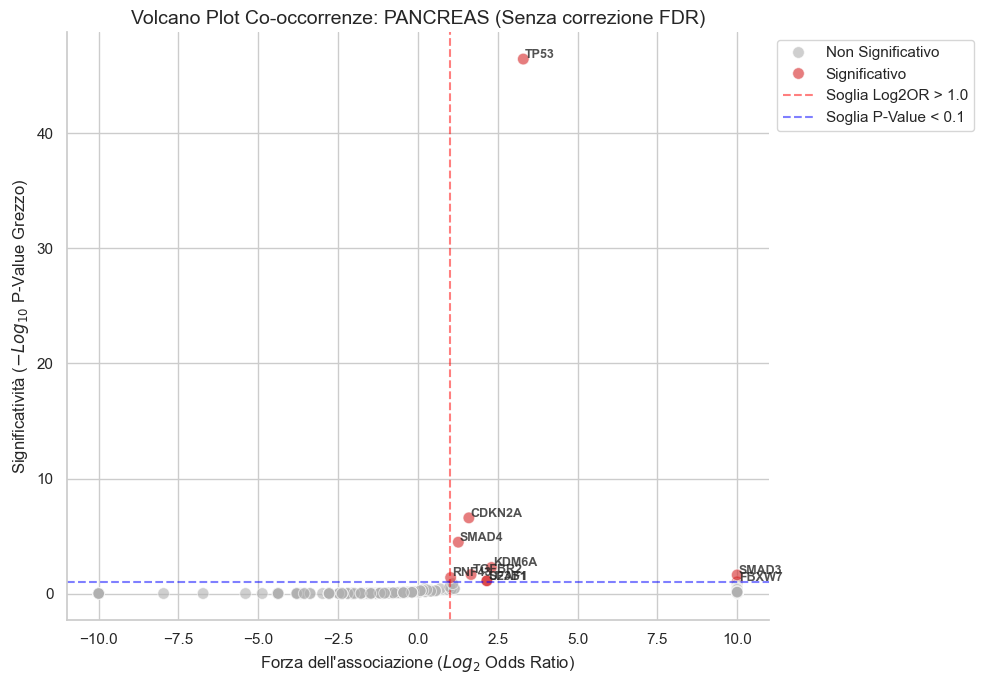


--- 📈 VISUALIZZAZIONE: PANCREAS ---
[*] Geni totali mappati: 462
[*] Geni sopra la soglia di significatività: 10


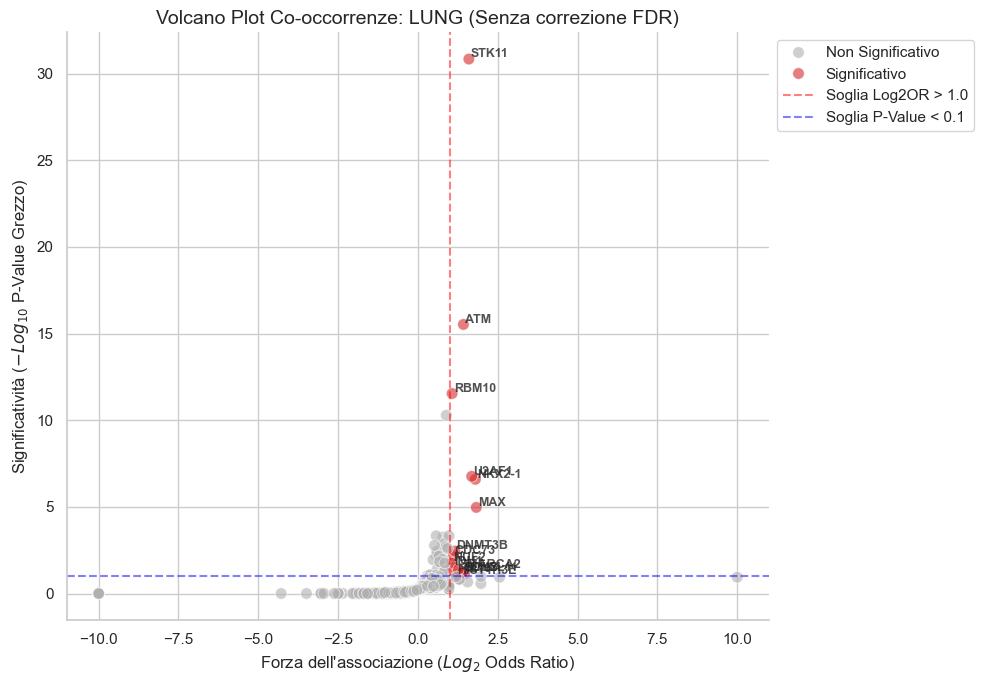


--- 📈 VISUALIZZAZIONE: LUNG ---
[*] Geni totali mappati: 512
[*] Geni sopra la soglia di significatività: 15


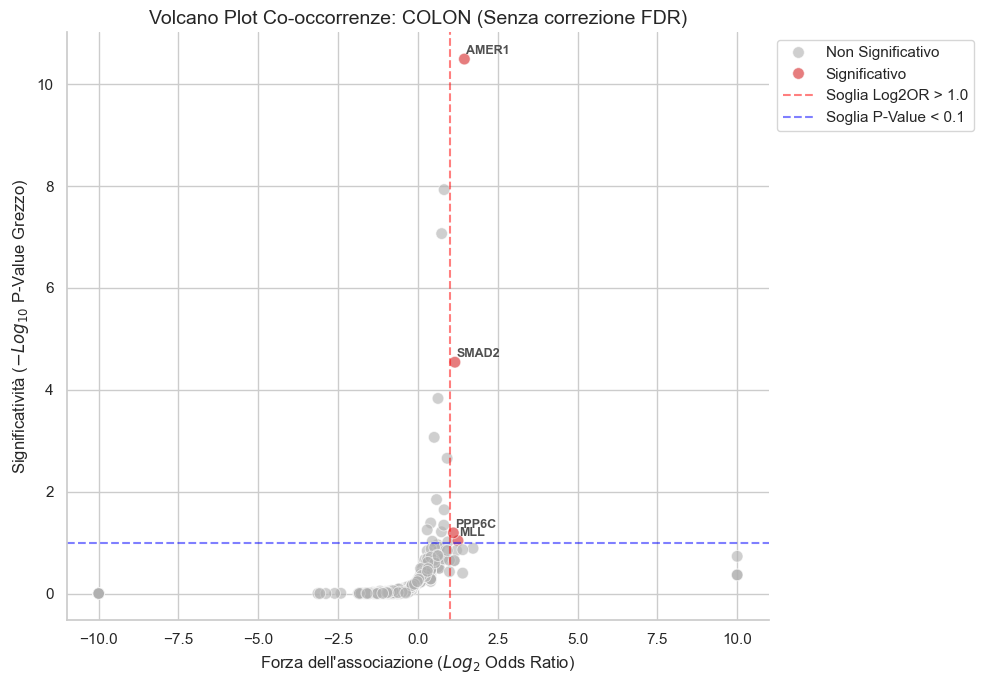


--- 📈 VISUALIZZAZIONE: COLON ---
[*] Geni totali mappati: 512
[*] Geni sopra la soglia di significatività: 4


In [8]:
# ==========================================
# CELLA 6: VOLCANO PLOT (VERSIONE P-VALUE GREZZO)
# ==========================================
def plot_volcano(df_results, cohort_name, log2or_thresh, p_thresh):
    """
    Genera un Volcano Plot basato sul P-Value grezzo.
    Asse X: Log2 Odds Ratio (Forza dell'associazione)
    Asse Y: -Log10 P-Value (Significatività statistica)
    """
    if df_results is None or df_results.empty:
        print(f"[!] Dati insufficienti per il Volcano Plot di {cohort_name}")
        return
    
    df_plot = df_results.copy()
    
    # Trasformazione Logaritmica dell'asse Y (P-Value grezzo)
    # Usiamo 1e-300 per evitare errori matematici con p-value pari a 0
    df_plot['neg_log10_p'] = -np.log10(df_plot['P_Value'] + 1e-300)
    
    # Definizione dello stato in base alle variabili globali
    cond_sig = (df_plot['Log2OR'] >= log2or_thresh) & (df_plot['P_Value'] <= p_thresh)
    df_plot['Stato'] = np.where(cond_sig, 'Significativo', 'Non Significativo')
    
    # Setup del grafico
    plt.figure(figsize=(10, 7))
    
    # Plot dei punti
    scatter = sns.scatterplot(
        data=df_plot, 
        x='Log2OR', 
        y='neg_log10_p', 
        hue='Stato',
        palette={'Significativo': '#d62728', 'Non Significativo': '#b0b0b0'},
        alpha=0.6,
        s=70,
        edgecolor='w'
    )
    
    # Linee tratteggiate per le soglie impostate nella Cella 0
    plt.axvline(x=log2or_thresh, color='red', linestyle='--', alpha=0.5, label=f'Soglia Log2OR > {log2or_thresh}')
    plt.axhline(y=-np.log10(p_thresh), color='blue', linestyle='--', alpha=0.5, label=f'Soglia P-Value < {p_thresh}')
    
    # Annotazione dei geni significativi (solo quelli che superano entrambe le soglie)
    sig_list = df_plot[cond_sig]
    for _, row in sig_list.iterrows():
        plt.text(
            row['Log2OR'] + 0.05, 
            row['neg_log10_p'] + 0.1, 
            row['Gene_B'], 
            fontsize=9, 
            weight='bold',
            alpha=0.8
        )
        
    # Personalizzazione etichette e titoli
    plt.title(f'Volcano Plot Co-occorrenze: {cohort_name.upper()} (Senza correzione FDR)', fontsize=14)
    plt.xlabel('Forza dell\'associazione ($Log_2$ Odds Ratio)', fontsize=12)
    plt.ylabel('Significatività ($-Log_{10}$ P-Value Grezzo)', fontsize=12)
    
    # Posizionamento legenda
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    sns.despine()
    plt.tight_layout()
    plt.show()

    # LOG DI DETTAGLIO
    print(f"\n--- 📈 VISUALIZZAZIONE: {cohort_name.upper()} ---")
    print(f"[*] Geni totali mappati: {len(df_plot)}")
    print(f"[*] Geni sopra la soglia di significatività: {cond_sig.sum()}")

# ==========================================
# ESECUZIONE
# ==========================================
for name, df in dfs_risultati.items():
    # Utilizza le variabili globali LOG2OR_THRESH e P_VALUE_THRESH definite nella Cella 0
    plot_volcano(df, name, log2or_thresh=LOG2OR_THRESH, p_thresh=P_VALUE_THRESH)

## Netework (star)

In [9]:
# ==========================================
# CELLA 7: NETWORK INTERATTIVA (FIX OVERFLOW)
# ==========================================
def build_interactive_significant_network(stat_file, mat_file, output_dir, cohort_name, target_gene=TARGET_GENE):
    if not os.path.exists(stat_file) or not os.path.exists(mat_file):
        print(f"[!] File necessari non trovati per {cohort_name}.")
        return None

    # 1. Carica i risultati e filtra
    df_stats = pd.read_csv(stat_file, sep='\t')
    df_sig = df_stats[(df_stats['Log2OR'] >= LOG2OR_THRESH) & (df_stats['P_Value'] <= P_VALUE_THRESH)].copy()

    if df_sig.empty:
        print(f"[-] {cohort_name.upper()}: Nessun gene supera le soglie per la rete.")
        return None

    coocc_matrix = pd.read_csv(mat_file, sep='\t', index_col=0)
    G = nx.Graph()
    G.add_node(target_gene, size=40, color='#d62728', title=f"TARGET: {target_gene}", font={'size': 20})

    # 4. Aggiungi i nodi e gli archi verso il target
    for _, row in df_sig.iterrows():
        gene_b = row['Gene_B']
        
        # --- FIX PROTEZIONE INFINITO ---
        log_val = row['Log2OR']
        # Se Log2OR è infinito, lo blocchiamo a un valore massimo (es. 10) per il calcolo grafico
        if np.isinf(log_val):
            log_val = 10.0 
        
        node_size = float(15 + (log_val * 8))
        # -------------------------------

        weight = int(row['Co_Occurrence_Count'])
        p_val = float(row['P_Value'])
        
        tooltip = f"Gene: {gene_b}<br>Log2OR: {row['Log2OR']:.2f}<br>P-Value: {p_val:.4e}<br>Co-occorrenze: {weight}"
        
        G.add_node(gene_b, size=node_size, color='#1f77b4', title=tooltip)
        G.add_edge(target_gene, gene_b, weight=weight, value=weight, color='#999999')

        # 5. Archi secondari tra i partner
        for other_gene in df_sig['Gene_B']:
            if gene_b != other_gene and gene_b in coocc_matrix.index and other_gene in coocc_matrix.columns:
                edge_weight = int(coocc_matrix.loc[gene_b, other_gene])
                if edge_weight > MIN_COOCCURRENCE_NETWORK:
                    G.add_edge(gene_b, other_gene, weight=edge_weight, value=edge_weight, color='#e0e0e0', alpha=0.5)

    # 6. Configurazione PyVis
    net = Network(notebook=True, cdn_resources='remote', height="700px", width="100%", bgcolor="#ffffff")
    net.from_nx(G)
    net.repulsion(node_distance=200)

    os.makedirs(output_dir, exist_ok=True)
    html_path = os.path.join(output_dir, f"Network_{cohort_name}.html")
    net.show(html_path)
    
    print(f"\n--- 🌐 NETWORK GENERATA: {cohort_name.upper()} ---")
    print(f"[*] Nodi totali: {G.number_of_nodes()}")
    print(f"✅ Rete salvata in: {html_path}")
    print(f"[->]Numero di archi: {G.number_of_edges()}")
    return G

# Esecuzione
for name in COORTI.keys():
    build_interactive_significant_network(
        f"./kras_{name}/co_occurr_output/Stat_Results_{name}.csv",
        f"./kras_{name}/co_occurr_output/M_cooccurrence_gene_gene_{name}.tsv",
        f"./kras_{name}/networks/",
        name
    )

./kras_pancreas/networks/Network_pancreas.html

--- 🌐 NETWORK GENERATA: PANCREAS ---
[*] Nodi totali: 11
✅ Rete salvata in: ./kras_pancreas/networks/Network_pancreas.html
[->]Numero di archi: 27
./kras_lung/networks/Network_lung.html

--- 🌐 NETWORK GENERATA: LUNG ---
[*] Nodi totali: 16
✅ Rete salvata in: ./kras_lung/networks/Network_lung.html
[->]Numero di archi: 21
./kras_colon/networks/Network_colon.html

--- 🌐 NETWORK GENERATA: COLON ---
[*] Nodi totali: 5
✅ Rete salvata in: ./kras_colon/networks/Network_colon.html
[->]Numero di archi: 5


In [15]:
# ==========================================
# CELLA 7: CALCOLO METRICHE DI RETE E IDENTIFICAZIONE HUB
# ==========================================

import networkx as nx
import pandas as pd
import os

def calculate_network_metrics(stat_file, coocc_matrix_file, output_dir, cohort_name):
    print(f"\n--- 📊 CALCOLO METRICHE DI RETE: {cohort_name.upper()} ---")
    
    if not os.path.exists(stat_file) or not os.path.exists(coocc_matrix_file):
        print(f"[!] File mancanti per {cohort_name}. Salto.")
        return None
        
    # 1. Lettura file risultati e RI-APPLICAZIONE FILTRI STATISTICI
    stat_df = pd.read_csv(stat_file, sep='\t')
    
    # Filtriamo per trovare i partner validi come fatto per il Plot
    sig_genes_df = stat_df[(stat_df['P_Value'] <= P_VALUE_THRESH) & 
                           (stat_df['Log2OR'] >= LOG2OR_THRESH)]
    
    valid_genes = sig_genes_df['Gene_B'].tolist()
    if TARGET_GENE not in valid_genes:
        valid_genes.append(TARGET_GENE)
        
    # 2. Caricamento della matrice di co-occorrenza gene-gene globale
    coocc_df = pd.read_csv(coocc_matrix_file, sep='\t', index_col=0)
    
    # 3. Costruzione del Grafo (NetworkX)
    G = nx.Graph()
    
    # Aggiunta Nodi validati
    for gene in valid_genes:
        if gene in coocc_df.columns:
            G.add_node(gene)
            
    # Aggiunta Archi
    for i in range(len(valid_genes)):
        for j in range(i + 1, len(valid_genes)):
            g1 = valid_genes[i]
            g2 = valid_genes[j]
            
            if g1 in coocc_df.columns and g2 in coocc_df.columns:
                weight = coocc_df.loc[g1, g2]
                
                # Crea l'arco se supera il filtro MIN_COOCCURRENCE_NETWORK 
                # o se è direttamente connesso al TARGET_GENE (KRAS)
                if weight >= MIN_COOCCURRENCE_NETWORK or (g1 == TARGET_GENE or g2 == TARGET_GENE):
                    G.add_edge(g1, g2, weight=weight)
                    
    # 4. Calcolo Metriche Topologiche
    if G.number_of_nodes() == 0:
        print("[!] Nessun nodo nella rete per calcolare le metriche.")
        return None
        
    degree_cent = nx.degree_centrality(G)
    betweenness_cent = nx.betweenness_centrality(G)
    try:
        eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)
    except:
        eigenvector_cent = nx.degree_centrality(G) # Fallback in caso di mancata convergenza

    # Nuove metriche da calcolare prima del ciclo 'for node in G.nodes():'
    clustering_coeffs = nx.clustering(G)
    closeness_cent = nx.closeness_centrality(G)
    
    metrics_data = []
    for node in G.nodes():
        metrics_data.append({
            'Gene': node,
            'Degree': G.degree(node),
            'Degree_Centrality': round(degree_cent.get(node, 0), 4),
            'Betweenness_Centrality': round(betweenness_cent.get(node, 0), 4),
            'Eigenvector_Centrality': round(eigenvector_cent.get(node, 0), 4),
            'Closeness_Centrality': round(closeness_cent.get(node, 0), 4), # NUOVO
            'Clustering_Coefficient': round(clustering_coeffs.get(node, 0), 4) # NUOVO
        })
        
    metrics_df = pd.DataFrame(metrics_data)
    # Ordiniamo i risultati in base al grado di connessione per trovare subito gli HUB
    metrics_df = metrics_df.sort_values(by='Degree_Centrality', ascending=False)
    
    # 5. Salvataggio su file CSV
    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"Network_Metrics_{cohort_name}.csv")
    metrics_df.to_csv(out_path, sep='\t', index=False)
    
    print(f"[*] Nodi: {G.number_of_nodes()} | Archi: {G.number_of_edges()}")
    if not metrics_df.empty:
        print(f"[*] Top 3 Hub identificati: {metrics_df['Gene'].head(3).tolist()}")
    print(f"✅ Metriche salvate in: {out_path}")
    
    return metrics_df

# ==========================================
# ESECUZIONE PER TUTTE LE COORTI
# ==========================================
dfs_metriche = {}
for name in COORTI.keys():
    dfs_metriche[name] = calculate_network_metrics(
        stat_file=f"./kras_{name}/co_occurr_output/Stat_Results_{name}.csv",
        coocc_matrix_file=f"./kras_{name}/co_occurr_output/M_cooccurrence_gene_gene_{name}.tsv",
        output_dir=f"./kras_{name}/networks/",
        cohort_name=name
    )


--- 📊 CALCOLO METRICHE DI RETE: PANCREAS ---
[*] Nodi: 11 | Archi: 27
[*] Top 3 Hub identificati: ['KRAS', 'TP53', 'CDKN2A']
✅ Metriche salvate in: ./kras_pancreas/networks/Network_Metrics_pancreas.csv

--- 📊 CALCOLO METRICHE DI RETE: LUNG ---
[*] Nodi: 16 | Archi: 22
[*] Top 3 Hub identificati: ['KRAS', 'STK11', 'RBM10']
✅ Metriche salvate in: ./kras_lung/networks/Network_Metrics_lung.csv

--- 📊 CALCOLO METRICHE DI RETE: COLON ---
[*] Nodi: 5 | Archi: 5
[*] Top 3 Hub identificati: ['KRAS', 'AMER1', 'SMAD2']
✅ Metriche salvate in: ./kras_colon/networks/Network_Metrics_colon.csv


# ANALISI GLOBALE

## Config

In [10]:
# ==========================================
# CONFIGURAZIONE GLOABLE
# ==========================================

# Soglie Statistiche
TARGET_GENE = 'KRAS'
P_VALUE_THRESH_GLOBAL = 0.05   # Significatività statistica grezza
LOG2OR_THRESH_GLOBAL = 3.0      # Forza dell'associazione (1.0 raddoppia le probabilità)

# Filtri Grafici (per Heatmap e Network)
MIN_COOCCURRENCE_NETWORK_GLOBAL = 10  # Minimo pazienti comuni per disegnare un arco tra due geni partner
TOP_GENES_HEATMAP_GLOBAL = 20         # Quanti geni mostrare nella heatmap iniziale

MIN_COOCCURRENCE_NETWORK_GLOBAL=5 #valore standard per network

# Percorsi Cartelle
COORTI = {
    "pancreas": "./kras_pancreas",
    "lung": "./kras_lung",
    "colon": "./kras_colon"
}

print(f"⚙️ Parametri impostati:  con p-value < {P_VALUE_THRESH_GLOBAL} e Log2OR > {LOG2OR_THRESH_GLOBAL}")

# ==========================================
# SELEZIONE MODALITÀ DI ANALISI
# ==========================================
# 1 = Solo Mutazioni (SNV)
# 2 = Solo CNA (Amplificazioni/Delezioni)
# 3 = Solo SV (Varianti Strutturali)
# 4 = Integrata (Mut + CNA + SV) 

ANALYSIS_MODE = 1

⚙️ Parametri impostati:  con p-value < 0.05 e Log2OR > 3.0


## Matrici + test statistico (insieme perché sì)

In [11]:
# ==========================================
# CELLA 8: ANALISI GLOBALE GENE-GENE (ALL-VS-ALL)
# ==========================================
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import time
import os
import numpy as np
import pandas as pd

def run_global_analysis(path_cohort, cohort_name, output_base, min_mutations=5):
    # Mapping per trovare il file generato nella Cella 4
    labels = {1: "MUT", 2: "CNA", 3: "SV", 4: "INTEGRATED"}
    tag = labels.get(ANALYSIS_MODE, "INTEGRATED")
    
    file_path = f"{path_cohort}/co_occurr_output/M_binary_{cohort_name}_{tag}.csv"
    
    if not os.path.exists(file_path):
        print(f"[!] Errore: Matrice non trovata per {cohort_name} in {file_path}")
        return
    
    # Caricamento matrice binaria
    matrix = pd.read_csv(file_path, sep='\t', index_col=0)
    
    # Filtro frequenza: analizziamo solo geni con almeno 'min_mutations' alterazioni
    frequent_genes = matrix.columns[matrix.sum() >= min_mutations]
    matrix_filtered = matrix[frequent_genes]
    
    genes = matrix_filtered.columns
    n = len(genes)
    n_pairs_total = n * (n - 1) // 2
    results = []
    
    print(f"\n>>> AVVIO ANALISI GLOBALE: {cohort_name.upper()} ({tag})")
    print(f"[*] Geni filtrati (presenza >= {min_mutations}): {n}")
    print(f"[*] Coppie totali da testare: {n_pairs_total}")

    start_time = time.time()
    
    # Iterazione sulle coppie
    for i in range(n):
        for j in range(i + 1, n):
            g1, g2 = genes[i], genes[j]
            
            # Calcolo rapido pazienti condivisi
            shared = (matrix_filtered[g1] & matrix_filtered[g2]).sum()
            
            # Se non hanno nemmeno un paziente in comune, inutile fare il test
            if shared == 0: continue
            
            g1_only = matrix_filtered[g1].sum() - shared
            g2_only = matrix_filtered[g2].sum() - shared
            neither = len(matrix_filtered) - (shared + g1_only + g2_only)
            
            # Test di Fisher (Co-occorrenza positiva)
            odds, p = stats.fisher_exact([[shared, g1_only], [g2_only, neither]], alternative='greater')
            
            # SALVATAGGIO PER VOLCANO PLOT:
            # Teniamo tutte le coppie con p < 0.1 per avere il "background" nel grafico
            if p < 0.1:
                log2or = np.log2(odds) if odds > 0 else 10.0
                results.append({
                    'Gene1': g1, 
                    'Gene2': g2, 
                    'Shared_Count': int(shared), 
                    'P_Value': p, 
                    'Log2OR': log2or
                })
        
        if i % 100 == 0 and i > 0:
            print(f"    ...elaborati {i}/{n} geni...")

    df_global = pd.DataFrame(results)
    
    if not df_global.empty:
        # Correzione FDR Benjamini-Hochberg su tutti i test salvati
        # Questo darà una colonna FDR realistica per il Volcano Plot
        _, fdr, _, _ = multipletests(df_global['P_Value'], method='fdr_bh')
        df_global['FDR'] = fdr
        
        # Ordinamento per significatività (P-value grezzo)
        df_global = df_global.sort_values('P_Value')
        
        # Salvataggio
        os.makedirs(output_base, exist_ok=True)
        out_file = f"{output_base}/Global_Network_Stats_{cohort_name}_{tag}.csv"
        df_global.to_csv(out_file, sep='\t', index=False)
        
        end_time = time.time()
        n_sig_fdr = len(df_global[df_global['FDR'] < 0.05])
        n_sig_top = len(df_global[(df_global['FDR'] < 0.05) & (df_global['Log2OR'] >= LOG2OR_THRESH_GLOBAL)])
        
        print(f"✅ Completato in {round(end_time - start_time, 2)}s")
        print(f"[*] Coppie salvate nel file (p < 0.1): {len(df_global)}")
        print(f"[*] Di cui con FDR < 0.05: {n_sig_fdr}")
        print(f"[*] Di cui 'TOP' (Log2OR > {LOG2OR_THRESH_GLOBAL}): {n_sig_top}")
    else:
        print(f"[!] Nessuna associazione trovata nemmeno con p < 0.1")

# --- ESECUZIONE ---
GLOBAL_MAIN_DIR = "./global_analysis"
os.makedirs(GLOBAL_MAIN_DIR, exist_ok=True)

for name, path in COORTI.items():
    tumor_global_dir = os.path.join(GLOBAL_MAIN_DIR, name)
    run_global_analysis(
        path_cohort=path, 
        cohort_name=name, 
        output_base=tumor_global_dir,
        min_mutations=5 
    )


>>> AVVIO ANALISI GLOBALE: PANCREAS (MUT)
[*] Geni filtrati (presenza >= 5): 242
[*] Coppie totali da testare: 29161
    ...elaborati 100/242 geni...
    ...elaborati 200/242 geni...
✅ Completato in 3.76s
[*] Coppie salvate nel file (p < 0.1): 5849
[*] Di cui con FDR < 0.05: 1010
[*] Di cui 'TOP' (Log2OR > 3.0): 972

>>> AVVIO ANALISI GLOBALE: LUNG (MUT)
[*] Geni filtrati (presenza >= 5): 491
[*] Coppie totali da testare: 120295
    ...elaborati 100/491 geni...
    ...elaborati 200/491 geni...
    ...elaborati 300/491 geni...
    ...elaborati 400/491 geni...
✅ Completato in 21.21s
[*] Coppie salvate nel file (p < 0.1): 26685
[*] Di cui con FDR < 0.05: 12796
[*] Di cui 'TOP' (Log2OR > 3.0): 3430

>>> AVVIO ANALISI GLOBALE: COLON (MUT)
[*] Geni filtrati (presenza >= 5): 497
[*] Coppie totali da testare: 123256
    ...elaborati 100/497 geni...
    ...elaborati 200/497 geni...
    ...elaborati 300/497 geni...
    ...elaborati 400/497 geni...
✅ Completato in 28.47s
[*] Coppie salvate nel f

## Plot

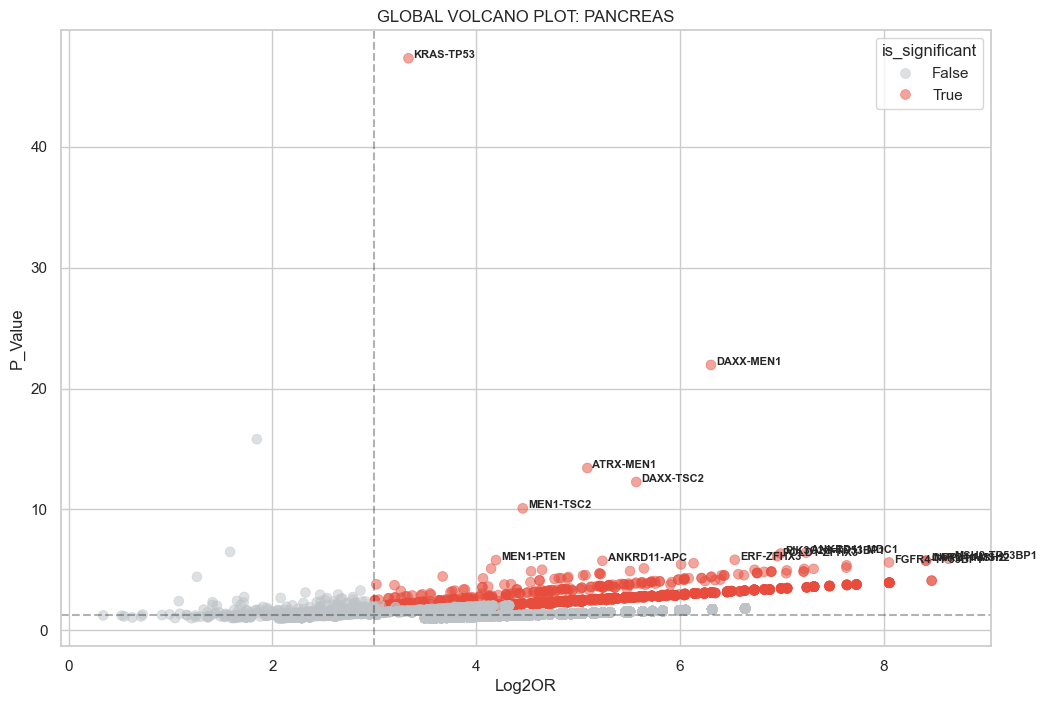

--- 📈 REPORT GRAFICO: PANCREAS ---
[*] Coppie caricate dal file: 5849
[*] Coppie con FDR < 0.05: 1010
[*] Coppie con FDR < 0.05 E Log2OR > 3.0: 972
✅ Volcano Plot salvato in: ./global_analysis/pancreas/plots\Volcano_Global_pancreas_MUT.png



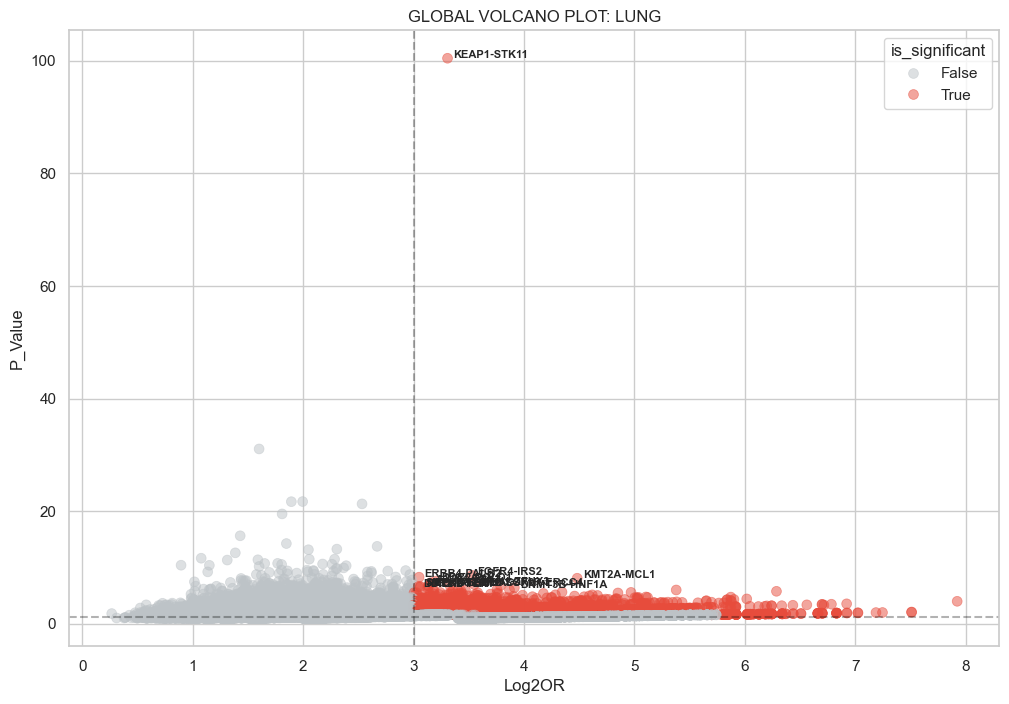

--- 📈 REPORT GRAFICO: LUNG ---
[*] Coppie caricate dal file: 26685
[*] Coppie con FDR < 0.05: 12796
[*] Coppie con FDR < 0.05 E Log2OR > 3.0: 3430
✅ Volcano Plot salvato in: ./global_analysis/lung/plots\Volcano_Global_lung_MUT.png



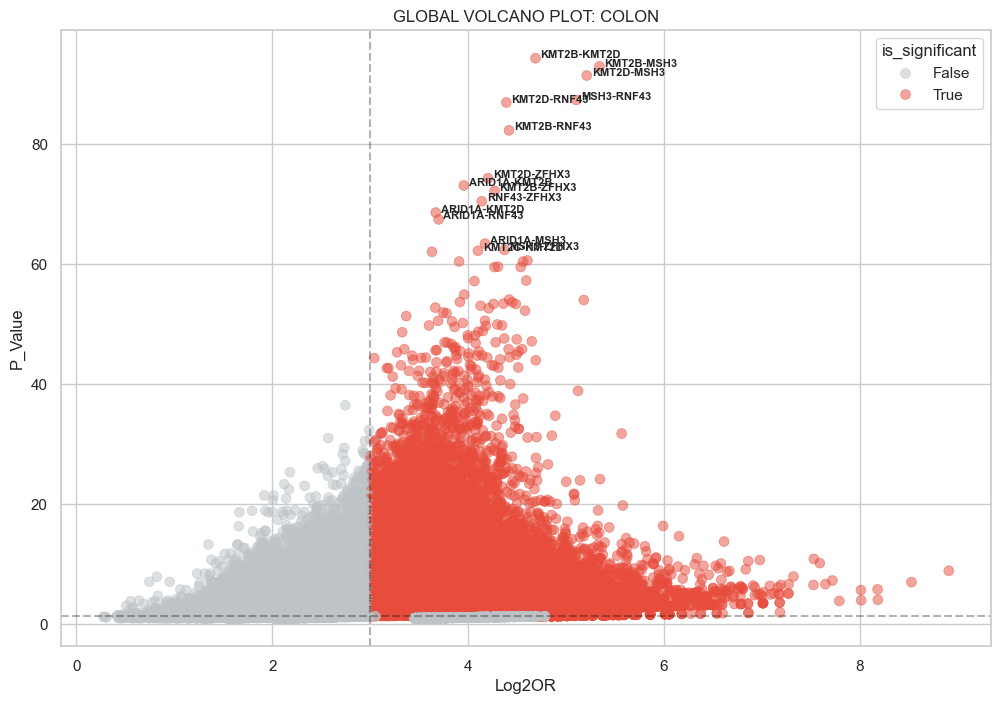

--- 📈 REPORT GRAFICO: COLON ---
[*] Coppie caricate dal file: 93284
[*] Coppie con FDR < 0.05: 86189
[*] Coppie con FDR < 0.05 E Log2OR > 3.0: 52169
✅ Volcano Plot salvato in: ./global_analysis/colon/plots\Volcano_Global_colon_MUT.png



In [12]:
# ==========================================
# CELLA 9: VOLCANO PLOT GLOBALE (FIXED)
# ==========================================
def plot_global_volcano(global_csv, cohort_name, output_dir):
    if not os.path.exists(global_csv):
        return
        
    df = pd.read_csv(global_csv, sep='\t')
    if df.empty: return

    plt.figure(figsize=(12, 8))
    
    # Applichiamo le soglie reali per la colorazione
    # Usiamo 0.05 per l'FDR e la tua variabile per il Log2OR
    df['is_significant'] = (df['FDR'] < 0.05) & (df['Log2OR'] >= LOG2OR_THRESH_GLOBAL)
    
    sns.scatterplot(
        data=df, x='Log2OR', y=-np.log10(df['P_Value']),
        hue='is_significant', 
        palette={True: '#e74c3c', False: '#bdc3c7'},
        alpha=0.5, edgecolor=None, s=50
    )
    
    # Annotiamo solo le vere TOP (quelle che passano i filtri)
    top_labels = df[df['is_significant']].nsmallest(15, 'FDR')
    for _, row in top_labels.iterrows():
        plt.text(row['Log2OR'] + 0.05, -np.log10(row['P_Value']), 
                 f"{row['Gene1']}-{row['Gene2']}", 
                 fontsize=8, weight='bold')

    plt.axvline(LOG2OR_THRESH_GLOBAL, color='black', linestyle='--', alpha=0.3)
    plt.axhline(-np.log10(P_VALUE_THRESH_GLOBAL), color='black', linestyle='--', alpha=0.3)
    
    plt.title(f"GLOBAL VOLCANO PLOT: {cohort_name.upper()}")
    
    os.makedirs(output_dir, exist_ok=True)
    save_path = os.path.join(output_dir, f"Volcano_Global_{cohort_name}_{tag}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    # --- ORA I PRINT SARANNO REALI ---
    total_in_file = len(df)
    passing_fdr = len(df[df['FDR'] < 0.05])
    passing_both = df['is_significant'].sum()

    print(f"--- 📈 REPORT GRAFICO: {cohort_name.upper()} ---")
    print(f"[*] Coppie caricate dal file: {total_in_file}")
    print(f"[*] Coppie con FDR < 0.05: {passing_fdr}")
    print(f"[*] Coppie con FDR < 0.05 E Log2OR > {LOG2OR_THRESH_GLOBAL}: {passing_both}")
    print(f"✅ Volcano Plot salvato in: {save_path}\n")
    plt.close()
    
# --- ESECUZIONE ---
for name in COORTI.keys():
    tag = "INTEGRATED" if ANALYSIS_MODE == 4 else "MUT"
    csv_path = f"./global_analysis/{name}/Global_Network_Stats_{name}_{tag}.csv"
    plot_global_dir = f"./global_analysis/{name}/plots"
    
    plot_global_volcano(csv_path, name, plot_global_dir)

## Network (full)

In [13]:
# ==========================================
# CELLA 10: NETWORK GLOBALE INTERATTIVA
# ==========================================
from pyvis.network import Network
import networkx as nx

def build_global_network(global_csv, cohort_name, output_dir):
    if not os.path.exists(global_csv):
        return
        
    df = pd.read_csv(global_csv, sep='\t')
    
    # --- FILTRO AGGRESSIVO PER LA VISUALIZZAZIONE ---
    # Usiamo le tue variabili globali + un filtro sulla forza dell'associazione
    # Nel Colon, se 52k coppie passano Log2OR > 3, alziamo l'asticella qui per chiarezza
    df_sig = df[
        (df['FDR'] < 0.001) & 
        (df['Log2OR'] > 4.0) & 
        (df['Shared_Count'] >= MIN_COOCCURRENCE_NETWORK_GLOBAL)
    ].copy()
    
    if df_sig.empty or len(df_sig) > 5000:
        # Se sono troppi, prendiamo solo i top 500 per evitare crash
        df_sig = df_sig.nsmallest(500, 'FDR')
        print(f"[*] Network {cohort_name.upper()}: Visualizzazione limitata ai top 500 archi per leggibilità.")

    G = nx.Graph()
    for _, row in df_sig.iterrows():
        # Lo spessore dell'arco dipende dal Log2OR
        G.add_edge(row['Gene1'], row['Gene2'], weight=row['Log2OR'], title=f"Shared: {row['Shared_Count']}")

    # Creazione Network Pyvis
    net = Network(notebook=True, cdn_resources='remote', height="800px", width="100%", bgcolor="#ffffff")
    net.from_nx(G)
    
    # Personalizzazione estetica
    for node in net.nodes:
        # Il Target Gene (KRAS) lo facciamo risaltare
        if node['id'] == TARGET_GENE:
            node['color'] = '#e74c3c' # Rosso
            node['size'] = 35
            node['font'] = {'size': 20, 'face': 'Arial Black'}
        else:
            node['color'] = '#3498db' # Blu
            node['size'] = 15

    # Impostazioni di fisica per separare bene i cluster
    net.toggle_physics(True)
    net.set_options("""
    var options = {
      "physics": {
        "forceAtlas2Based": {"gravitationalConstant": -100, "centralGravity": 0.01, "springLength": 100},
        "minVelocity": 0.75,
        "solver": "forceAtlas2Based"
      }
    }
    """)

    os.makedirs(output_dir, exist_ok=True)
    tag = "INTEGRATED" if ANALYSIS_MODE == 4 else "MUT"
    html_path = os.path.join(output_dir, f"Global_Network_{cohort_name}_{tag}.html")
    net.show(html_path)
    
    print(f"--- 🕸️ NETWORK REPORT: {cohort_name.upper()} ---")
    print(f"[*] Nodi (Geni): {G.number_of_nodes()}")
    print(f"[*] Archi (Interazioni): {G.number_of_edges()}")
    print(f"✅ Network interattiva salvata: {html_path}\n")

# --- ESECUZIONE ---
for name in COORTI.keys():
    tag = "INTEGRATED" if ANALYSIS_MODE == 4 else "MUT"
    csv_path = f"./global_analysis/{name}/Global_Network_Stats_{name}_{tag}.csv"
    net_dir = f"./global_analysis/{name}/network"
    
    build_global_analysis_network = build_global_network(csv_path, name, net_dir)

./global_analysis/pancreas/network\Global_Network_pancreas_MUT.html
--- 🕸️ NETWORK REPORT: PANCREAS ---
[*] Nodi (Geni): 7
[*] Archi (Interazioni): 6
✅ Network interattiva salvata: ./global_analysis/pancreas/network\Global_Network_pancreas_MUT.html

./global_analysis/lung/network\Global_Network_lung_MUT.html
--- 🕸️ NETWORK REPORT: LUNG ---
[*] Nodi (Geni): 33
[*] Archi (Interazioni): 17
✅ Network interattiva salvata: ./global_analysis/lung/network\Global_Network_lung_MUT.html

[*] Network COLON: Visualizzazione limitata ai top 500 archi per leggibilità.
./global_analysis/colon/network\Global_Network_colon_MUT.html
--- 🕸️ NETWORK REPORT: COLON ---
[*] Nodi (Geni): 164
[*] Archi (Interazioni): 500
✅ Network interattiva salvata: ./global_analysis/colon/network\Global_Network_colon_MUT.html

